In [1]:
import pandas as pd
import numpy as np

from collections import defaultdict
from pathlib import Path
from typing import Optional

from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', None)

# 데이터 개별 처리

In [2]:
key_id_icu = pd.read_feather("/home/DAHS1/gangmin/my_research/processed/key_id_icu.ftr")

df_weight = pd.read_feather("/home/DAHS1/gangmin/my_research/processed/df_weight.ftr")
df_height = pd.read_feather("/home/DAHS1/gangmin/my_research/processed/df_height.ftr")

patient_df = pd.read_parquet("/home/DAHS1/gangmin/my_research/data/mimic-iv/core/parquet/patients.parquet")
admissions_df = pd.read_parquet("/home/DAHS1/gangmin/my_research/data/mimic-iv/core/parquet/admissions.parquet")

In [3]:
d_icd_procedures_df = pd.read_parquet("/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/hosp_parquet/d_icd_procedures.parquet")
diagnoses_icd_df = pd.read_parquet("/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/hosp_parquet/diagnoses_icd.parquet")
d_icd_diagnoses_df = pd.read_parquet("/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/hosp_parquet/d_icd_diagnoses.parquet")
procedures_icd_df = pd.read_parquet("/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/hosp_parquet/procedures_icd.parquet")

In [4]:
procedure_history_df = procedures_icd_df.merge(d_icd_procedures_df, on=["icd_code", "icd_version"], how="left")
procedure_history_df.head()

,subject_id,hadm_id,seq_num,chartdate,icd_code,icd_version,long_title
0,10000032,22595853,1,2180-05-07,5491,9,Percutaneous abdominal drainage
1,10000032,22841357,1,2180-06-27,5491,9,Percutaneous abdominal drainage
2,10000032,25742920,1,2180-08-06,5491,9,Percutaneous abdominal drainage
3,10000068,25022803,1,2160-03-03,8938,9,Other nonoperative respiratory measurements
4,10000117,27988844,1,2183-09-19,0QS734Z,10,Reposition Left Upper Femur with Internal Fixa...


In [5]:
diagnosis_history_df = diagnoses_icd_df.merge(d_icd_diagnoses_df, on=["icd_code", "icd_version"], how="left")
diagnosis_history_df.head()

,subject_id,hadm_id,seq_num,icd_code,icd_version,long_title
0,10000032,22595853,1,5723,9,Portal hypertension
1,10000032,22595853,2,78959,9,Other ascites
2,10000032,22595853,3,5715,9,Cirrhosis of liver without mention of alcohol
3,10000032,22595853,4,07070,9,Unspecified viral hepatitis C without hepatic ...
4,10000032,22595853,5,496,9,"Chronic airway obstruction, not elsewhere clas..."


In [6]:
def has_circulatory(icd_list):
    for code in icd_list:
        code_str = str(code).upper()

        # ICD-10
        if code_str.startswith('I'):
            return 1

        # ICD-9
        if code_str[:3].isdigit():
            num = int(code_str[:3])
            if 390 <= num <= 459:
                return 1
    return 0


def has_respiratory(icd_list):
    for code in icd_list:
        code_str = str(code).upper()

        # ICD-10
        if code_str.startswith('J'):
            return 1

        # ICD-9
        if code_str[:3].isdigit():
            num = int(code_str[:3])
            if 460 <= num <= 519:
                return 1
    return 0


def build_diagnosis_prompt(diag):

    diag = diag.sort_values(["subject_id", "hadm_id", "seq_num"])

    def _process_group(df):
        titles = df["long_title"].dropna().str.strip()

        titles = pd.unique(titles)

        # ICD 기반 category
        icd_list = df["icd_code"].tolist()

        has_cardio = has_circulatory(icd_list)
        has_resp = has_respiratory(icd_list)

        parts = []

        if has_resp:
            parts.append("respiratory disease present")
        if has_cardio:
            parts.append("cardiovascular disease present")

        titles = titles[:10] # length 조절

        if len(titles) > 0:
            parts.append("Clinical history: " + "; ".join(titles))

        return "Diagnoses: " + ". ".join(parts) + "."

    grouped = (
        diag.groupby(["subject_id", "hadm_id"])
        .apply(_process_group)
        .reset_index(name="diag_prompt")
    )

    return grouped

In [7]:
diag = diagnosis_history_df.sort_values(["subject_id", "hadm_id", "seq_num"])
diag_df = build_diagnosis_prompt(diag)
diag_df

/tmp/ipykernel_3081091/1491589722.py:63: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  diag.groupby(["subject_id", "hadm_id"])


,subject_id,hadm_id,diag_prompt
0,10000032,22595853,Diagnoses: respiratory disease present. Clinic...
1,10000032,22841357,Diagnoses: respiratory disease present. Clinic...
2,10000032,25742920,Diagnoses: respiratory disease present. Clinic...
3,10000032,29079034,Diagnoses: respiratory disease present. cardio...
4,10000068,25022803,"Diagnoses: Clinical history: Alcohol abuse, un..."
...,...,...,...
430847,19999828,25744818,Diagnoses: respiratory disease present. cardio...
430848,19999828,29734428,Diagnoses: respiratory disease present. cardio...
430849,19999840,21033226,Diagnoses: respiratory disease present. cardio...
430850,19999840,26071774,Diagnoses: cardiovascular disease present. Cli...


In [8]:
print(diag_df['diag_prompt'].iloc[8])

Diagnoses: cardiovascular disease present. Clinical history: Dysphagia, unspecified; Other specified symptoms and signs involving the circulatory and respiratory systems; Angiodysplasia of stomach and duodenum without bleeding; Gastro-esophageal reflux disease without esophagitis; Diaphragmatic hernia without obstruction or gangrene; Anxiety disorder, unspecified; Nonrheumatic mitral (valve) prolapse; Age-related osteoporosis without current pathological fracture; Personal history of nicotine dependence.


In [9]:
# 동일 날짜(chartdate)의 procedure를 묶음.
def build_procedure_by_date(proc):
    proc = proc.copy()
    proc["chartdate"] = pd.to_datetime(proc["chartdate"])
    proc = proc.sort_values(["subject_id", "hadm_id", "chartdate", "seq_num"])

    grouped = (
        proc.groupby(["subject_id", "hadm_id", "chartdate"])["long_title"]
        .apply(lambda titles: "; ".join(titles.dropna().str.strip()))
        .reset_index()
        .rename(columns={"long_title": "proc_prompt"})
    )
    return grouped


# 동일 날짜(chartdate)의 procedure를 누적하며, hadm_id에 따라 reset
def build_cumulative_procedure(proc_by_date):
    proc_by_date = proc_by_date.copy()

    proc_by_date = proc_by_date.sort_values(
        ["subject_id", "hadm_id", "chartdate"]
    )

    def accumulate(series):
        seen = []
        result = []
        for v in series:
            if pd.notna(v) and v.strip():
                seen.append(v)
            result.append("; ".join(seen))
        return result

    proc_by_date["proc_prompt"] = (
        proc_by_date.groupby(["subject_id", "hadm_id"])["proc_prompt"]
        .transform(accumulate)
    )

    return proc_by_date

In [10]:
# procedure는 사건 단위이므로 중복 삭제할 필요 없음.
proc_df = build_procedure_by_date(procedure_history_df)
proc_cum = build_cumulative_procedure(proc_df)
proc_cum

,subject_id,hadm_id,chartdate,proc_prompt
0,10000032,22595853,2180-05-07,Percutaneous abdominal drainage
1,10000032,22841357,2180-06-27,Percutaneous abdominal drainage
2,10000032,25742920,2180-08-06,Percutaneous abdominal drainage
3,10000068,25022803,2160-03-03,Other nonoperative respiratory measurements
4,10000117,27988844,2183-09-19,Reposition Left Upper Femur with Internal Fixa...
...,...,...,...,...
358532,19999840,21033226,2164-09-14,Insertion of endotracheal tube; Continuous inv...
358533,19999840,21033226,2164-09-16,Insertion of endotracheal tube; Continuous inv...
358534,19999840,26071774,2164-07-25,Magnetic resonance imaging of brain and brain ...
358535,19999987,23865745,2145-11-02,Continuous invasive mechanical ventilation for...


In [11]:
def build_demographics(patients, admissions, height):
    demo = admissions[["subject_id", "hadm_id"]].copy()

    demo = demo.merge(
        patients[["subject_id", "gender", "anchor_age"]],
        on="subject_id",
        how="left",
    )

    adm_cols = ["hadm_id"]
    for col in ["insurance", "marital_status", "race"]:
        if col in admissions.columns:
            adm_cols.append(col)
    demo = demo.merge(admissions[adm_cols], on="hadm_id", how="left")
    demo = demo.merge(height, on=["subject_id"], how="left")

    def _format_demo(row):
        parts = []

        # Age + Gender
        age = row.get("anchor_age", None)
        gender = row.get("gender", None)
        if pd.notna(age) and pd.notna(gender):
            gender_str = "male" if str(gender).upper() == "M" else "female"
            parts.append(f"{int(age)}-year-old {gender_str}")

        # Race
        race = row.get("race", None)
        if pd.notna(race) and str(race).strip():
            parts.append(str(race).strip().lower())

        # Marital status
        marital = row.get("marital_status", None)
        if pd.notna(marital) and str(marital).strip():
            parts.append(str(marital).strip().lower())

        # Insurance
        insurance = row.get("insurance", None)
        if pd.notna(insurance) and str(insurance).strip():
            parts.append(str(insurance).strip().lower())

        return "Demographics: " + ", ".join(parts) + "." if parts else ""

    demo["demo_prompt"] = demo.apply(_format_demo, axis=1)
    return demo[["subject_id", "hadm_id", "demo_prompt", "height"]]


# 또다른 시간 컬럼을 가진 weight 데이터를 처리함.
def process_weight_df(weight_df):
    weight_df = weight_df.copy()
    weight_df["charttime"] = pd.to_datetime(weight_df["charttime"])
    
    weight_df = weight_df.sort_values(["subject_id", "hadm_id", "charttime"])

    weight_df = weight_df.rename(columns={"valuenum": "weight"})

    return weight_df[["subject_id", "hadm_id", "charttime", "weight"]]


# procedure와 weight의 발생 시점을 합쳐 환자별 timeline을 생성
def build_timeline(proc_by_date, weight_by_time):
    
    timeline = pd.concat([
        proc_by_date[["subject_id", "hadm_id", "chartdate"]],
        weight_by_time.rename(columns={"charttime": "chartdate"})[["subject_id", "hadm_id", "chartdate"]],
    ], ignore_index=True)

    timeline = timeline.drop_duplicates()
    timeline = timeline.sort_values(["subject_id", "hadm_id", "chartdate"])

    return timeline


def build_time_aware_prompts(timeline, demo_df, diag_df, proc_df, weight_df):
    
    df = timeline.copy()

    # static
    df = df.merge(demo_df, on=["subject_id", "hadm_id"], how="left")
    df = df.merge(diag_df, on=["subject_id", "hadm_id"], how="left")

    # procedure (dynamic)
    df = df.merge(proc_df, on=["subject_id", "hadm_id", "chartdate"], how="left")
    df["proc_prompt"] = df.groupby(["subject_id", "hadm_id"])["proc_prompt"].ffill()

    # weight (forward fill)
    df = df.merge(weight_df, on=["subject_id", "hadm_id", "chartdate"], how="left")
    df["weight"] = df.groupby(["subject_id", "hadm_id"])["weight"].ffill()

    return df


def build_prompt(row):
    parts = []

    if pd.notna(row["demo_prompt"]):
        parts.append(row["demo_prompt"])

    height = row.get("height", None)
    weight = row.get("weight", None)

    if pd.notna(height) and pd.notna(weight):
        parts.append(f"Body size: {height:.1f} cm, {weight:.1f} kg.")
    elif pd.notna(weight):
        parts.append(f"Weight: {weight:.1f} kg.")
    elif pd.notna(height):
        parts.append(f"Height: {height:.1f} cm.")

    if pd.notna(row["diag_prompt"]):
        parts.append(row["diag_prompt"])

    if pd.notna(row["proc_prompt"]):
        parts.append(f"Procedures so far: {row['proc_prompt']}.")

    return "\n".join(parts)

In [12]:
demo_df = build_demographics(patient_df, admissions_df, df_height)
demo_df['demo_prompt'].iloc[0]

processed_weight_df = process_weight_df(df_weight)
timeline = build_timeline(proc_df, processed_weight_df)

clinical_prompt_df = build_time_aware_prompts(
    timeline,
    demo_df,
    diag_df,
    proc_cum,
    processed_weight_df.rename(columns={"charttime": "chartdate"})
)

clinical_prompt_df["clinical_prompt"] = clinical_prompt_df.apply(build_prompt, axis=1)

In [13]:
clinical_prompt_df

,subject_id,hadm_id,chartdate,demo_prompt,height,diag_prompt,proc_prompt,weight,clinical_prompt
0,10000032.0,22595853.0,2180-05-07 00:00:00,"Demographics: 52-year-old female, white, widow...",NaN,Diagnoses: respiratory disease present. Clinic...,Percutaneous abdominal drainage,NaN,"Demographics: 52-year-old female, white, widow..."
1,10000032.0,22841357.0,2180-06-27 00:00:00,"Demographics: 52-year-old female, white, widow...",NaN,Diagnoses: respiratory disease present. Clinic...,Percutaneous abdominal drainage,NaN,"Demographics: 52-year-old female, white, widow..."
2,10000032.0,25742920.0,2180-08-06 00:00:00,"Demographics: 52-year-old female, white, widow...",NaN,Diagnoses: respiratory disease present. Clinic...,Percutaneous abdominal drainage,NaN,"Demographics: 52-year-old female, white, widow..."
3,10000068.0,25022803.0,2160-03-03 00:00:00,"Demographics: 19-year-old female, white, singl...",NaN,"Diagnoses: Clinical history: Alcohol abuse, un...",Other nonoperative respiratory measurements,NaN,"Demographics: 19-year-old female, white, singl..."
4,10000117.0,27988844.0,2183-09-19 00:00:00,"Demographics: 48-year-old female, white, divor...",NaN,Diagnoses: cardiovascular disease present. Cli...,Reposition Left Upper Femur with Internal Fixa...,NaN,"Demographics: 48-year-old female, white, divor..."
...,...,...,...,...,...,...,...,...,...
1922629,19999987.0,23865745.0,2145-11-04 14:00:00,"Demographics: 57-year-old female, unknown, other.",NaN,Diagnoses: cardiovascular disease present. Cli...,Continuous invasive mechanical ventilation for...,94.0,"Demographics: 57-year-old female, unknown, oth..."
1922630,19999987.0,23865745.0,2145-11-04 20:35:00,"Demographics: 57-year-old female, unknown, other.",NaN,Diagnoses: cardiovascular disease present. Cli...,Continuous invasive mechanical ventilation for...,94.0,"Demographics: 57-year-old female, unknown, oth..."
1922631,19999987.0,23865745.0,2145-11-04 20:47:00,"Demographics: 57-year-old female, unknown, other.",NaN,Diagnoses: cardiovascular disease present. Cli...,Continuous invasive mechanical ventilation for...,94.0,"Demographics: 57-year-old female, unknown, oth..."
1922632,19999987.0,23865745.0,2145-11-04 20:48:00,"Demographics: 57-year-old female, unknown, other.",NaN,Diagnoses: cardiovascular disease present. Cli...,Continuous invasive mechanical ventilation for...,94.0,"Demographics: 57-year-old female, unknown, oth..."


In [14]:
print(clinical_prompt_df["clinical_prompt"].iloc[0])

Demographics: 52-year-old female, white, widowed, other.
Diagnoses: respiratory disease present. Clinical history: Portal hypertension; Other ascites; Cirrhosis of liver without mention of alcohol; Unspecified viral hepatitis C without hepatic coma; Chronic airway obstruction, not elsewhere classified; Bipolar disorder, unspecified; Posttraumatic stress disorder; Personal history of tobacco use.
Procedures so far: Percutaneous abdominal drainage.


In [15]:
print(clinical_prompt_df["clinical_prompt"].iloc[46])

Demographics: 68-year-old female, black/african american, married, medicare.
Body size: 158.2 cm, 65.0 kg.
Diagnoses: respiratory disease present. cardiovascular disease present. Clinical history: Chronic obstructive pulmonary disease with (acute) exacerbation; Acute and subacute hepatic failure without coma; Shock, unspecified; Acute respiratory failure with hypercapnia; Acute respiratory failure with hypoxia; Atrioventricular block, complete; Acute embolism and thrombosis of deep veins of right upper extremity; Unspecified atrial fibrillation; Thrombocytopenia, unspecified; Cardiac arrest, cause unspecified.
Procedures so far: Respiratory Ventilation, 24-96 Consecutive Hours; Insertion of Endotracheal Airway into Trachea, Via Natural or Artificial Opening; Performance of Cardiac Pacing, Continuous; Performance of Cardiac Output, Single, Manual; Insertion of Endotracheal Airway into Trachea, Via Natural or Artificial Opening.


In [16]:
clinical_prompt_df.head()

,subject_id,hadm_id,chartdate,demo_prompt,height,diag_prompt,proc_prompt,weight,clinical_prompt
0,10000032.0,22595853.0,2180-05-07,"Demographics: 52-year-old female, white, widow...",NaN,Diagnoses: respiratory disease present. Clinic...,Percutaneous abdominal drainage,NaN,"Demographics: 52-year-old female, white, widow..."
1,10000032.0,22841357.0,2180-06-27,"Demographics: 52-year-old female, white, widow...",NaN,Diagnoses: respiratory disease present. Clinic...,Percutaneous abdominal drainage,NaN,"Demographics: 52-year-old female, white, widow..."
2,10000032.0,25742920.0,2180-08-06,"Demographics: 52-year-old female, white, widow...",NaN,Diagnoses: respiratory disease present. Clinic...,Percutaneous abdominal drainage,NaN,"Demographics: 52-year-old female, white, widow..."
3,10000068.0,25022803.0,2160-03-03,"Demographics: 19-year-old female, white, singl...",NaN,"Diagnoses: Clinical history: Alcohol abuse, un...",Other nonoperative respiratory measurements,NaN,"Demographics: 19-year-old female, white, singl..."
4,10000117.0,27988844.0,2183-09-19,"Demographics: 48-year-old female, white, divor...",NaN,Diagnoses: cardiovascular disease present. Cli...,Reposition Left Upper Femur with Internal Fixa...,NaN,"Demographics: 48-year-old female, white, divor..."


In [17]:
key_id_icu

,subject_id,hadm_id,stay_id,admittime,dischtime,edregtime,edouttime,admission_type,admission_location,discharge_location,insurance,language,marital_status,race,first_careunit,last_careunit,intime,outtime,los
0,10001884,26184834.0,37510196.0,2131-01-07 20:39:00,2131-01-20 05:15:00,2131-01-07 13:36:00,2131-01-07 22:13:00,OBSERVATION ADMIT,EMERGENCY ROOM,DIED,Medicare,ENGLISH,MARRIED,BLACK/AFRICAN AMERICAN,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2131-01-11 04:20:05,2131-01-20 08:27:30,9.171817
1,10002428,23473524.0,35479615.0,2156-05-11 14:49:00,2156-05-22 14:16:00,2156-05-11 11:29:00,2156-05-11 16:53:00,EW EMER.,EMERGENCY ROOM,CHRONIC/LONG TERM ACUTE CARE,Medicare,ENGLISH,WIDOWED,WHITE,Surgical Intensive Care Unit (SICU),Medical Intensive Care Unit (MICU),2156-05-11 14:49:34,2156-05-22 14:16:46,10.977222
2,10002428,28662225.0,33987268.0,2156-04-12 14:16:00,2156-04-29 16:26:00,2156-04-12 09:56:00,2156-04-12 17:11:00,EW EMER.,EMERGENCY ROOM,SKILLED NURSING FACILITY,Medicare,ENGLISH,WIDOWED,WHITE,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2156-04-12 16:24:18,2156-04-17 15:57:08,4.981134
3,10002428,28662225.0,38875437.0,2156-04-12 14:16:00,2156-04-29 16:26:00,2156-04-12 09:56:00,2156-04-12 17:11:00,EW EMER.,EMERGENCY ROOM,SKILLED NURSING FACILITY,Medicare,ENGLISH,WIDOWED,WHITE,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2156-04-19 18:11:19,2156-04-26 18:58:41,7.032894
4,10003400,20214994.0,32128372.0,2137-02-24 10:00:00,2137-03-19 15:45:00,None,None,URGENT,TRANSFER FROM SKILLED NURSING FACILITY,CHRONIC/LONG TERM ACUTE CARE,Medicare,ENGLISH,MARRIED,BLACK/AFRICAN AMERICAN,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),2137-02-25 23:37:19,2137-03-10 21:29:36,12.911308
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14141,19998330,24096838.0,33428243.0,2178-11-27 21:51:00,2178-12-01 17:10:00,2178-11-27 19:21:00,2178-11-27 22:53:00,EW EMER.,EMERGENCY ROOM,HOME HEALTH CARE,Other,ENGLISH,MARRIED,BLACK/AFRICAN AMERICAN,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2178-11-27 22:53:00,2178-11-29 21:29:39,1.942118
14142,19998843,24842066.0,30988867.0,2187-02-05 09:27:00,2187-02-08 17:28:00,2187-02-05 08:44:00,2187-02-05 10:12:00,EW EMER.,EMERGENCY ROOM,DIED,Other,?,SINGLE,UNKNOWN,Trauma SICU (TSICU),Trauma SICU (TSICU),2187-02-05 10:12:00,2187-02-08 18:19:39,3.338646
14143,19999287,20175828.0,35165301.0,2197-08-03 20:58:00,2197-08-18 15:37:00,2197-08-03 19:34:00,2197-08-04 00:02:00,EW EMER.,EMERGENCY ROOM,HOSPICE,Medicare,ENGLISH,SINGLE,BLACK/AFRICAN AMERICAN,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),2197-08-04 00:02:00,2197-08-08 16:58:17,4.705752
14144,19999442,26785317.0,32336619.0,2148-11-19 10:00:00,2148-12-04 16:25:00,None,None,ELECTIVE,PHYSICIAN REFERRAL,REHAB,Medicaid,ENGLISH,DIVORCED,WHITE,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2148-11-19 14:23:43,2148-11-26 13:12:15,6.950370


In [18]:
def create_dynamic_hr_timeslots(icustays_df): 
    time_slots_list = []

    for idx, row in icustays_df.iterrows():
        hadm_id = row['hadm_id']
        stay_id = row['stay_id']
        intime = row['intime']
        outtime = row['outtime']

        hour_slot = 0
        slot_start = intime
        while slot_start < outtime: 
            slot_end = slot_start + pd.Timedelta(hours=1)
            time_slots_list.append({
                'hadm_id': hadm_id,
                'stay_id': stay_id,
                'hour_slot': hour_slot,
                'slot_start': slot_start,
                'slot_end': slot_end
            })

            hour_slot += 1
            slot_start = slot_end # 다음 hour slot 시작 시간
    
    time_slots_df = pd.DataFrame(time_slots_list)
    time_slots_df['stay_id'] = time_slots_df['stay_id'].astype('int32')
    return time_slots_df

time_slots_df = create_dynamic_hr_timeslots(key_id_icu)
time_slots_df['hadm_id'] = time_slots_df['hadm_id'].astype(int)

In [19]:
time_slots_df

,hadm_id,stay_id,hour_slot,slot_start,slot_end
0,26184834,37510196,0,2131-01-11 04:20:05,2131-01-11 05:20:05
1,26184834,37510196,1,2131-01-11 05:20:05,2131-01-11 06:20:05
2,26184834,37510196,2,2131-01-11 06:20:05,2131-01-11 07:20:05
3,26184834,37510196,3,2131-01-11 07:20:05,2131-01-11 08:20:05
4,26184834,37510196,4,2131-01-11 08:20:05,2131-01-11 09:20:05
...,...,...,...,...,...
1618766,23865745,36195440,42,2145-11-04 16:59:00,2145-11-04 17:59:00
1618767,23865745,36195440,43,2145-11-04 17:59:00,2145-11-04 18:59:00
1618768,23865745,36195440,44,2145-11-04 18:59:00,2145-11-04 19:59:00
1618769,23865745,36195440,45,2145-11-04 19:59:00,2145-11-04 20:59:00


In [20]:
clinical_prompt_df = clinical_prompt_df[['subject_id', 'hadm_id', 'chartdate', 'clinical_prompt']]

In [21]:
clinical_prompt_df

,subject_id,hadm_id,chartdate,clinical_prompt
0,10000032.0,22595853.0,2180-05-07 00:00:00,"Demographics: 52-year-old female, white, widow..."
1,10000032.0,22841357.0,2180-06-27 00:00:00,"Demographics: 52-year-old female, white, widow..."
2,10000032.0,25742920.0,2180-08-06 00:00:00,"Demographics: 52-year-old female, white, widow..."
3,10000068.0,25022803.0,2160-03-03 00:00:00,"Demographics: 19-year-old female, white, singl..."
4,10000117.0,27988844.0,2183-09-19 00:00:00,"Demographics: 48-year-old female, white, divor..."
...,...,...,...,...
1922629,19999987.0,23865745.0,2145-11-04 14:00:00,"Demographics: 57-year-old female, unknown, oth..."
1922630,19999987.0,23865745.0,2145-11-04 20:35:00,"Demographics: 57-year-old female, unknown, oth..."
1922631,19999987.0,23865745.0,2145-11-04 20:47:00,"Demographics: 57-year-old female, unknown, oth..."
1922632,19999987.0,23865745.0,2145-11-04 20:48:00,"Demographics: 57-year-old female, unknown, oth..."


In [22]:
def match_prompt_time_slot_df(time_slots_df, clinical_prompt_df):
    slots = time_slots_df.copy()
    prompts = clinical_prompt_df.copy()


    merged = slots.merge(prompts, on="hadm_id", how="left")

    in_range = merged[(merged["chartdate"] >= merged["slot_start"]) &(merged["chartdate"] < merged["slot_end"])]

    in_range = in_range.sort_values("chartdate")
    in_range_latest = (
        in_range.groupby(["hadm_id", "hour_slot"])
        .tail(1) # 슬롯별 최신값 선택
        .reset_index(drop=True)
    )

    # 원본 슬롯에 다시 merge
    result = slots.merge(
        in_range_latest[
            ["hadm_id", "hour_slot", "clinical_prompt"]
        ],
        on=["hadm_id", "hour_slot"],
        how="left"
    )

    result = result.sort_values(["hadm_id", "stay_id", "slot_start"])

    result["clinical_prompt"] = (result.groupby("hadm_id")["clinical_prompt"].ffill()) # ffill 

    return result

final_processed_prompt_df = match_prompt_time_slot_df(time_slots_df, clinical_prompt_df)
final_processed_prompt_df = (final_processed_prompt_df.sort_values(["hadm_id", "stay_id", "hour_slot"]))

final_processed_prompt_df["clinical_prompt"] = (final_processed_prompt_df.groupby("hadm_id")["clinical_prompt"].bfill()) # bfill 

# 아무런 의료 기록이 없는 경우
final_processed_prompt_df["clinical_prompt"] = final_processed_prompt_df["clinical_prompt"].fillna("No clinical information available.")

# 환자별 Local prompt id
final_processed_prompt_df["prompt_id"] = (
    final_processed_prompt_df.groupby("hadm_id")["clinical_prompt"]
    .transform(lambda x: pd.factorize(x)[0])
)

final_processed_prompt_df = final_processed_prompt_df.reset_index(drop=True)
final_processed_prompt_df

,hadm_id,stay_id,hour_slot,slot_start,slot_end,clinical_prompt,prompt_id
0,20001305,36916968,0,2178-03-25 02:59:09,2178-03-25 03:59:09,"Demographics: 76-year-old female, white, singl...",0
1,20001305,36916968,1,2178-03-25 03:59:09,2178-03-25 04:59:09,"Demographics: 76-year-old female, white, singl...",0
2,20001305,36916968,2,2178-03-25 04:59:09,2178-03-25 05:59:09,"Demographics: 76-year-old female, white, singl...",0
3,20001305,36916968,3,2178-03-25 05:59:09,2178-03-25 06:59:09,"Demographics: 76-year-old female, white, singl...",0
4,20001305,36916968,4,2178-03-25 06:59:09,2178-03-25 07:59:09,"Demographics: 76-year-old female, white, singl...",0
...,...,...,...,...,...,...,...
1618766,29999098,33475199,261,2128-06-20 22:18:00,2128-06-20 23:18:00,"Demographics: 76-year-old male, white, married...",4
1618767,29999098,33475199,262,2128-06-20 23:18:00,2128-06-21 00:18:00,"Demographics: 76-year-old male, white, married...",4
1618768,29999098,33475199,263,2128-06-21 00:18:00,2128-06-21 01:18:00,"Demographics: 76-year-old male, white, married...",4
1618769,29999098,33475199,264,2128-06-21 01:18:00,2128-06-21 02:18:00,"Demographics: 76-year-old male, white, married...",4


In [23]:
clinical_prompt_df = final_processed_prompt_df.to_feather("/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/clinical_prompt_df.ftr")
clinical_prompt_df = pd.read_feather("/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/clinical_prompt_df.ftr")
clinical_prompt_df

,hadm_id,stay_id,hour_slot,slot_start,slot_end,clinical_prompt,prompt_id
0,20001305,36916968,0,2178-03-25 02:59:09,2178-03-25 03:59:09,"Demographics: 76-year-old female, white, singl...",0
1,20001305,36916968,1,2178-03-25 03:59:09,2178-03-25 04:59:09,"Demographics: 76-year-old female, white, singl...",0
2,20001305,36916968,2,2178-03-25 04:59:09,2178-03-25 05:59:09,"Demographics: 76-year-old female, white, singl...",0
3,20001305,36916968,3,2178-03-25 05:59:09,2178-03-25 06:59:09,"Demographics: 76-year-old female, white, singl...",0
4,20001305,36916968,4,2178-03-25 06:59:09,2178-03-25 07:59:09,"Demographics: 76-year-old female, white, singl...",0
...,...,...,...,...,...,...,...
1618766,29999098,33475199,261,2128-06-20 22:18:00,2128-06-20 23:18:00,"Demographics: 76-year-old male, white, married...",4
1618767,29999098,33475199,262,2128-06-20 23:18:00,2128-06-21 00:18:00,"Demographics: 76-year-old male, white, married...",4
1618768,29999098,33475199,263,2128-06-21 00:18:00,2128-06-21 01:18:00,"Demographics: 76-year-old male, white, married...",4
1618769,29999098,33475199,264,2128-06-21 01:18:00,2128-06-21 02:18:00,"Demographics: 76-year-old male, white, married...",4


In [25]:
print(clinical_prompt_df['clinical_prompt'].iloc[0])

Demographics: 76-year-old female, white, single, medicare.
Body size: 152.0 cm, 44.0 kg.
Diagnoses: respiratory disease present. cardiovascular disease present. Clinical history: Acute respiratory failure with hypoxia; Non-ST elevation (NSTEMI) myocardial infarction; Other shock; Acute kidney failure with tubular necrosis; Cachexia; Acquired coagulation factor deficiency; Secondary and unspecified malignant neoplasm of lymph node, unspecified; Malignant neoplasm of lower lobe, left bronchus or lung; Hypovolemia; Acute embolism and thrombosis of right popliteal vein.
Procedures so far: Respiratory Ventilation, 24-96 Consecutive Hours; Insertion of Endotracheal Airway into Trachea, Via Natural or Artificial Opening.


---

# 2. (구)Demo embedding 처리 방식

In [4]:
key_df = key_id_icu[['subject_id', 'hadm_id', 'stay_id']]

## 1. BMI

In [10]:
df_height = df_height.merge(key_df, on=['subject_id'], how='left')
df_height

,subject_id,height,hadm_id,stay_id
0,10001884.0,158.163390,26184834.0,37510196.0
1,10002428.0,149.895000,23473524.0,35479615.0
2,10002428.0,149.895000,28662225.0,33987268.0
3,10002428.0,149.895000,28662225.0,38875437.0
4,10003400.0,165.660000,20214994.0,32128372.0
...,...,...,...,...
12109,19997367.0,147.876645,21508795.0,36980198.0
12110,19997473.0,157.677500,27787494.0,32134105.0
12111,19998843.0,180.170000,24842066.0,30988867.0
12112,19999287.0,167.111364,20175828.0,35165301.0


In [11]:
df_weight_mean = (df_weight.groupby(['hadm_id', 'stay_id'], as_index=False)['valuenum'].mean().round(2))
df_weight_mean = df_weight_mean.merge(key_df, on=['hadm_id', 'stay_id'], how='left')
df_weight_mean.rename(columns={'valuenum':'weight'}, inplace=True)

df_bmi = df_height.merge(df_weight_mean, on=['hadm_id', 'stay_id'])
df_bmi= df_bmi.drop(columns=['subject_id_y', 'subject_id_x'])
df_bmi['bmi'] = (df_bmi['weight']/((df_bmi['height']/100)**2)).round(1)
df_bmi

,height,hadm_id,stay_id,weight,bmi
0,158.163390,26184834.0,37510196.0,65.00,26.0
1,149.895000,23473524.0,35479615.0,48.46,21.6
2,149.895000,28662225.0,38875437.0,43.21,19.2
3,165.660000,20214994.0,32128372.0,93.10,33.9
4,165.660000,23559586.0,38383343.0,97.99,35.7
...,...,...,...,...,...
11238,147.876645,21508795.0,36980198.0,50.15,22.9
11239,157.677500,27787494.0,32134105.0,63.13,25.4
11240,180.170000,24842066.0,30988867.0,72.82,22.4
11241,167.111364,20175828.0,35165301.0,86.31,30.9


In [12]:
df_bmi['bmi'].describe()

count    11243.000000
mean        28.698550
std          7.617505
min          9.900000
25%         23.700000
50%         27.400000
75%         32.100000
max         94.300000
Name: bmi, dtype: float64

In [13]:
# 이걸 어쩌지? -> BMI binnning
df_bmi[df_bmi['bmi'] > 94]

,height,hadm_id,stay_id,weight,bmi
5311,152.705714,23032853.0,35516732.0,219.8,94.3


### WHO 기준 BMI 분류

| BMI 범위 (kg/m²) | 분류 (Category) |
|------------------|----------------|
| < 18.5           | Underweight    |
| 18.5 – 24.9      | Normal weight  |
| 25.0 – 29.9      | Overweight     |
| 30.0 – 34.9      | Obese Class I  |
| 35.0 – 39.9      | Obese Class II |
| ≥ 40.0           | Obese Class III|


<Axes: >

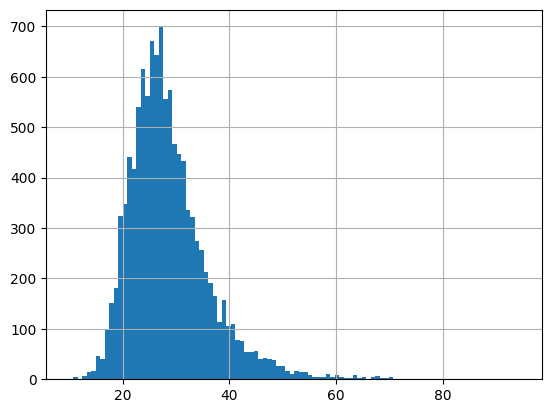

In [14]:
df_bmi['bmi'].hist(bins=100)

In [15]:
def bmi_binning(bmi):
    if pd.isna(bmi):
        return 'unknown'

    elif bmi < 18.5:
        return 'under'
    elif bmi < 25:
        return 'normal'
    elif bmi < 30:
        return 'overweight'
    elif bmi < 35:
        return 'obese1'
    elif bmi < 40:
        return 'obese2'
    else:
        return 'obese3'

In [16]:
df_bmi['bmi_bin'] = df_bmi['bmi'].apply(bmi_binning)
df_bmi = pd.get_dummies(df_bmi, columns=['bmi_bin'], prefix='bmi').astype(int)
df_bmi = df_bmi[['hadm_id', 'stay_id', 'bmi_under', 'bmi_normal', 'bmi_overweight', 'bmi_obese1', 'bmi_obese2', 'bmi_obese3']]

In [17]:
bmi_cols = ['bmi_under', 'bmi_normal', 'bmi_overweight', 'bmi_obese1', 'bmi_obese2', 'bmi_obese3']
df_bmi[bmi_cols].sum()

bmi_under          398
bmi_normal        3345
bmi_overweight    3551
bmi_obese1        2113
bmi_obese2         981
bmi_obese3         855
dtype: int64

In [18]:
df_bmi

,hadm_id,stay_id,bmi_under,bmi_normal,bmi_overweight,bmi_obese1,bmi_obese2,bmi_obese3
0,26184834,37510196,0,0,1,0,0,0
1,23473524,35479615,0,1,0,0,0,0
2,28662225,38875437,0,1,0,0,0,0
3,20214994,32128372,0,0,0,1,0,0
4,23559586,38383343,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...
11238,21508795,36980198,0,1,0,0,0,0
11239,27787494,32134105,0,0,1,0,0,0
11240,24842066,30988867,0,1,0,0,0,0
11241,20175828,35165301,0,0,0,1,0,0


## 2. Insurance, marital status, race

In [19]:
ins_mari_race_df = key_id_icu[['subject_id', 'hadm_id', 'stay_id', 'insurance', 'marital_status', 'race']]
ins_mari_race_df

,subject_id,hadm_id,stay_id,insurance,marital_status,race
0,10001884,26184834.0,37510196.0,Medicare,MARRIED,BLACK/AFRICAN AMERICAN
1,10002428,23473524.0,35479615.0,Medicare,WIDOWED,WHITE
2,10002428,28662225.0,33987268.0,Medicare,WIDOWED,WHITE
3,10002428,28662225.0,38875437.0,Medicare,WIDOWED,WHITE
4,10003400,20214994.0,32128372.0,Medicare,MARRIED,BLACK/AFRICAN AMERICAN
...,...,...,...,...,...,...
14141,19998330,24096838.0,33428243.0,Other,MARRIED,BLACK/AFRICAN AMERICAN
14142,19998843,24842066.0,30988867.0,Other,SINGLE,UNKNOWN
14143,19999287,20175828.0,35165301.0,Medicare,SINGLE,BLACK/AFRICAN AMERICAN
14144,19999442,26785317.0,32336619.0,Medicaid,DIVORCED,WHITE


In [20]:
# insurance one-hot encoding
ins_mari_race_df['insurance'].value_counts()

insurance
Medicare    6890
Other       6185
Medicaid    1071
Name: count, dtype: int64

In [21]:
insurance_onehot = pd.get_dummies(ins_mari_race_df['insurance'], prefix='ins').astype(int)
ins_mari_race_df = pd.concat([ins_mari_race_df, insurance_onehot], axis=1)
ins_mari_race_df

,subject_id,hadm_id,stay_id,insurance,marital_status,race,ins_Medicaid,ins_Medicare,ins_Other
0,10001884,26184834.0,37510196.0,Medicare,MARRIED,BLACK/AFRICAN AMERICAN,0,1,0
1,10002428,23473524.0,35479615.0,Medicare,WIDOWED,WHITE,0,1,0
2,10002428,28662225.0,33987268.0,Medicare,WIDOWED,WHITE,0,1,0
3,10002428,28662225.0,38875437.0,Medicare,WIDOWED,WHITE,0,1,0
4,10003400,20214994.0,32128372.0,Medicare,MARRIED,BLACK/AFRICAN AMERICAN,0,1,0
...,...,...,...,...,...,...,...,...,...
14141,19998330,24096838.0,33428243.0,Other,MARRIED,BLACK/AFRICAN AMERICAN,0,0,1
14142,19998843,24842066.0,30988867.0,Other,SINGLE,UNKNOWN,0,0,1
14143,19999287,20175828.0,35165301.0,Medicare,SINGLE,BLACK/AFRICAN AMERICAN,0,1,0
14144,19999442,26785317.0,32336619.0,Medicaid,DIVORCED,WHITE,1,0,0


In [22]:
# marital_status one-hot encoding
ins_mari_race_df['marital_status'].value_counts()

marital_status
MARRIED     5981
SINGLE      4187
WIDOWED     1876
DIVORCED    1151
Name: count, dtype: int64

In [23]:
marital_onehot = pd.get_dummies(ins_mari_race_df['marital_status'], prefix='mari').astype(int)
ins_mari_race_df = pd.concat([ins_mari_race_df, marital_onehot], axis=1)
ins_mari_race_df

,subject_id,hadm_id,stay_id,insurance,marital_status,race,ins_Medicaid,ins_Medicare,ins_Other,mari_DIVORCED,mari_MARRIED,mari_SINGLE,mari_WIDOWED
0,10001884,26184834.0,37510196.0,Medicare,MARRIED,BLACK/AFRICAN AMERICAN,0,1,0,0,1,0,0
1,10002428,23473524.0,35479615.0,Medicare,WIDOWED,WHITE,0,1,0,0,0,0,1
2,10002428,28662225.0,33987268.0,Medicare,WIDOWED,WHITE,0,1,0,0,0,0,1
3,10002428,28662225.0,38875437.0,Medicare,WIDOWED,WHITE,0,1,0,0,0,0,1
4,10003400,20214994.0,32128372.0,Medicare,MARRIED,BLACK/AFRICAN AMERICAN,0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14141,19998330,24096838.0,33428243.0,Other,MARRIED,BLACK/AFRICAN AMERICAN,0,0,1,0,1,0,0
14142,19998843,24842066.0,30988867.0,Other,SINGLE,UNKNOWN,0,0,1,0,0,1,0
14143,19999287,20175828.0,35165301.0,Medicare,SINGLE,BLACK/AFRICAN AMERICAN,0,1,0,0,0,1,0
14144,19999442,26785317.0,32336619.0,Medicaid,DIVORCED,WHITE,1,0,0,1,0,0,0


In [24]:
# race one-hot encoding
ins_mari_race_df['race'].value_counts()

race
WHITE                                        8861
BLACK/AFRICAN AMERICAN                       1441
UNKNOWN                                      1182
OTHER                                         539
WHITE - OTHER EUROPEAN                        294
HISPANIC/LATINO - PUERTO RICAN                238
WHITE - RUSSIAN                               215
ASIAN - CHINESE                               169
ASIAN                                         152
HISPANIC/LATINO - DOMINICAN                   128
BLACK/CAPE VERDEAN                            112
PORTUGUESE                                     91
BLACK/CARIBBEAN ISLAND                         89
UNABLE TO OBTAIN                               83
BLACK/AFRICAN                                  65
ASIAN - SOUTH EAST ASIAN                       50
HISPANIC OR LATINO                             49
AMERICAN INDIAN/ALASKA NATIVE                  48
ASIAN - ASIAN INDIAN                           40
WHITE - EASTERN EUROPEAN                     

In [25]:
race_mapping = {
    'ASIAN': 'ASIAN',
    'ASIAN - ASIAN INDIAN': 'ASIAN',
    'ASIAN - CHINESE': 'ASIAN', 
    'ASIAN - KOREAN': 'ASIAN', 
    'ASIAN - SOUTH EAST ASIAN': 'ASIAN',

    'BLACK/AFRICAN': 'BLACK', 
    'BLACK/AFRICAN AMERICAN': 'BLACK',
    'BLACK/CAPE VERDEAN': 'BLACK',
    'BLACK/CARIBBEAN ISLAND': 'BLACK', 

    'HISPANIC OR LATINO': 'HISPANIC/LATINO',
    'HISPANIC/LATINO - CENTRAL AMERICAN': 'HISPANIC/LATINO',
    'HISPANIC/LATINO - COLUMBIAN': 'HISPANIC/LATINO', 
    'HISPANIC/LATINO - CUBAN': 'HISPANIC/LATINO',
    'HISPANIC/LATINO - DOMINICAN': 'HISPANIC/LATINO', 
    'HISPANIC/LATINO - GUATEMALAN': 'HISPANIC/LATINO', 
    'HISPANIC/LATINO - HONDURAN': 'HISPANIC/LATINO',
    'HISPANIC/LATINO - MEXICAN': 'HISPANIC/LATINO', 
    'HISPANIC/LATINO - PUERTO RICAN': 'HISPANIC/LATINO', 
    'HISPANIC/LATINO - SALVADORAN': 'HISPANIC/LATINO',
    'PORTUGUESE': 'HISPANIC/LATINO',
    'SOUTH AMERICAN': 'HISPANIC/LATINO', 

    'WHITE': 'WHITE', 
    'WHITE - BRAZILIAN': 'WHITE', 
    'WHITE - EASTERN EUROPEAN': 'WHITE', 
    'WHITE - OTHER EUROPEAN': 'WHITE',
    'WHITE - RUSSIAN': 'WHITE', 

    'OTHER': 'OTHER',
    'AMERICAN INDIAN/ALASKA NATIVE': 'OTHER', 
    'MULTIPLE RACE/ETHNICITY': 'OTHER',
    'NATIVE HAWAIIAN OR OTHER PACIFIC ISLANDER': 'OTHER',

    'UNKNOWN': 'UNKNOWN',
    'UNABLE TO OBTAIN': 'UNKNOWN', 
    'PATIENT DECLINED TO ANSWER': 'UNKNOWN'
}

In [26]:
ins_mari_race_df['race'] = ins_mari_race_df['race'].map(race_mapping)
ins_mari_race_df['race'] = ins_mari_race_df['race'].fillna('OTHER')

ins_mari_race_df['race'] = (
    ins_mari_race_df
    .groupby('subject_id')['race']
    .transform(lambda x: x.mode().iloc[0])
)

check = ins_mari_race_df.groupby('subject_id')['race'].nunique()
assert (check == 1).all()

In [27]:
print("After Race Processing")
ins_mari_race_df['race'].value_counts()

After Race Processing


race
WHITE              9405
BLACK              1715
UNKNOWN            1295
HISPANIC/LATINO     668
OTHER               632
ASIAN               431
Name: count, dtype: int64

In [28]:
race_onehot = pd.get_dummies(ins_mari_race_df['race'], prefix='ethn').astype(int)
ins_mari_race_df = pd.concat([ins_mari_race_df, race_onehot], axis=1)

ins_mari_race_df = ins_mari_race_df.drop(columns=['insurance', 'marital_status','race'])
ins_mari_race_df

,subject_id,hadm_id,stay_id,ins_Medicaid,ins_Medicare,ins_Other,mari_DIVORCED,mari_MARRIED,mari_SINGLE,mari_WIDOWED,ethn_ASIAN,ethn_BLACK,ethn_HISPANIC/LATINO,ethn_OTHER,ethn_UNKNOWN,ethn_WHITE
0,10001884,26184834.0,37510196.0,0,1,0,0,1,0,0,0,1,0,0,0,0
1,10002428,23473524.0,35479615.0,0,1,0,0,0,0,1,0,0,0,0,0,1
2,10002428,28662225.0,33987268.0,0,1,0,0,0,0,1,0,0,0,0,0,1
3,10002428,28662225.0,38875437.0,0,1,0,0,0,0,1,0,0,0,0,0,1
4,10003400,20214994.0,32128372.0,0,1,0,0,1,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14141,19998330,24096838.0,33428243.0,0,0,1,0,1,0,0,0,1,0,0,0,0
14142,19998843,24842066.0,30988867.0,0,0,1,0,0,1,0,0,0,0,0,1,0
14143,19999287,20175828.0,35165301.0,0,1,0,0,0,1,0,0,1,0,0,0,0
14144,19999442,26785317.0,32336619.0,1,0,0,1,0,0,0,0,0,0,0,0,1


## 3. Age & Sex

- age 구하는 방법:
age_at_admit=anchor_age+(year(admittime)−anchor_year)

In [29]:
admit_time_df = admissions_df[['subject_id', 'hadm_id', 'admittime']]

age_df = admit_time_df.merge(patient_df, on=['subject_id'], how='left')
age_df['admittime'] = pd.to_datetime(age_df['admittime'])
age_df['age_at_admit'] = (age_df['anchor_age'] + (age_df['admittime'].dt.year - age_df['anchor_year']))

In [30]:
# age_df['is_mismatch'] = age_df['anchor_age'] != age_df['age_at_admit']
# age_df['mismatch_count'] = (age_df['anchor_age'] != age_df['age_at_admit']).astype(int)

# print(f"\n총 불일치 개수: {age_df['is_mismatch'].sum()}")
# print(f"일치율: {(age_df['anchor_age'] == age_df['age_at_admit']).mean() * 100:.2f}%")

In [31]:
age_df = age_df[['subject_id', 'hadm_id','age_at_admit', 'gender']]
age_sex_df = age_df.rename(columns={'age_at_admit':'age'})
age_sex_df

,subject_id,hadm_id,age,gender
0,10000032,22595853,52,F
1,10000032,22841357,52,F
2,10000032,25742920,52,F
3,10000032,29079034,52,F
4,10000068,25022803,19,F
...,...,...,...,...
431226,19999828,25744818,48,F
431227,19999828,29734428,46,F
431228,19999840,21033226,58,M
431229,19999840,26071774,58,M


## 4. Past ICD codes

In [32]:
diagnosis_icd = pd.read_parquet("/home/DAHS1/gangmin/my_research/data/mimic-iv/hosp/parquet/diagnoses_icd.parquet")

In [33]:
diag_merged = diagnosis_icd.merge(key_id_icu[['subject_id', 'hadm_id', 'admittime']], on=['subject_id', 'hadm_id'], how='left')
diag_merged.sort_values(by=['subject_id', 'admittime'], inplace=True)

In [34]:
diag_merged

,subject_id,hadm_id,seq_num,icd_code,icd_version,admittime
0,10000032,22595853,1,5723,9,NaT
1,10000032,22595853,2,78959,9,NaT
2,10000032,22595853,3,5715,9,NaT
3,10000032,22595853,4,07070,9,NaT
4,10000032,22595853,5,496,9,NaT
...,...,...,...,...,...,...
4787316,19999987,23865745,7,41401,9,2145-11-02 21:38:00
4787317,19999987,23865745,8,78039,9,2145-11-02 21:38:00
4787318,19999987,23865745,9,0413,9,2145-11-02 21:38:00
4787319,19999987,23865745,10,36846,9,2145-11-02 21:38:00


In [35]:
# ICD9 to ICD10 mapping
# 당장은 불필요

In [36]:
past_history_dict = defaultdict(list)

for subject_id, group in diag_merged.sort_values('admittime').groupby('subject_id'):
    past_codes = set()
    seen_hadm = set()

    for _, row in group.iterrows():
        current_hadm = row['hadm_id']
        icd_code = row['icd_code']

        if current_hadm not in seen_hadm:
            past_history_dict[(subject_id, current_hadm)] = list(past_codes)
            seen_hadm.add(current_hadm)

        past_codes.add(icd_code)

past_history_df = pd.DataFrame([{'subject_id': subject_id,'hadm_id': hadm_id,'past_icd_codes': codes} for (subject_id, hadm_id), codes in past_history_dict.items()])

In [37]:
past_history_df

,subject_id,hadm_id,past_icd_codes
0,10000032,22595853,[]
1,10000032,22841357,"[78959, 496, 29680, 07070, 30981, V1582, 5723,..."
2,10000032,25742920,"[07071, 2875, V08, 2761, 78959, 496, 3051, 296..."
3,10000032,29079034,"[07071, 2875, V08, 2761, 2767, 78959, 496, 305..."
4,10000068,25022803,[]
...,...,...,...
430847,19999828,25744818,[]
430848,19999828,29734428,"[Y929, T8141XA, K632, Z87891, E876, L02211, R1..."
430849,19999840,21033226,[]
430850,19999840,26071774,"[5180, 4019, 51881, 43811, E912, 2724, 9331, 4..."


In [38]:
test = past_history_df.copy()

In [39]:
"""
ICD Filtering
ICD9 기준
- 390-459: Diseases Of The Circulatory System
- 460-519: Diseases Of The Respiratory System

ICD10 기준
- I00-I99: Diseases of the circulatory system
- J00-J99: Diseases of the respiratory system
"""
def has_circulatory(icd_list):
    for code in icd_list:
        code_str = str(code)

        # ICD-10
        if code_str.startswith('I'):
            return 1

        # ICD-9
        if code_str[:3].isdigit():
            num = int(code_str[:3])
            if 390 <= num <= 459:
                return 1
    return 0


def has_respiratory(icd_list):
    for code in icd_list:
        code_str = str(code)

        # ICD-10
        if code_str.startswith('J'):
            return 1

        # ICD-9
        if code_str[:3].isdigit():
            num = int(code_str[:3])
            if 460 <= num <= 519:
                return 1
    return 0

past_history_df['circulatory'] = past_history_df['past_icd_codes'].apply(has_circulatory)
past_history_df['respiratory'] = past_history_df['past_icd_codes'].apply(has_respiratory)

In [40]:
past_history_df

,subject_id,hadm_id,past_icd_codes,circulatory,respiratory
0,10000032,22595853,[],0,0
1,10000032,22841357,"[78959, 496, 29680, 07070, 30981, V1582, 5723,...",0,1
2,10000032,25742920,"[07071, 2875, V08, 2761, 78959, 496, 3051, 296...",0,1
3,10000032,29079034,"[07071, 2875, V08, 2761, 2767, 78959, 496, 305...",0,1
4,10000068,25022803,[],0,0
...,...,...,...,...,...
430847,19999828,25744818,[],0,0
430848,19999828,29734428,"[Y929, T8141XA, K632, Z87891, E876, L02211, R1...",1,1
430849,19999840,21033226,[],0,0
430850,19999840,26071774,"[5180, 4019, 51881, 43811, E912, 2724, 9331, 4...",1,1


In [41]:
past_history_df = past_history_df[['subject_id', 'hadm_id', 'circulatory', 'respiratory']]
past_history_df

,subject_id,hadm_id,circulatory,respiratory
0,10000032,22595853,0,0
1,10000032,22841357,0,1
2,10000032,25742920,0,1
3,10000032,29079034,0,1
4,10000068,25022803,0,0
...,...,...,...,...
430847,19999828,25744818,0,0
430848,19999828,29734428,1,1
430849,19999840,21033226,0,0
430850,19999840,26071774,1,1


In [42]:
hist_cols = ['circulatory', 'respiratory']
past_history_df[hist_cols].sum()

circulatory    197075
respiratory    126759
dtype: int64

## Demographic Dataframe 취합

In [43]:
"""
# 사용해야 하는 df 목록
df_bmi: BMI (식별자: hadm_id, stay_id) - Outlier
ins_mari_race_df: 보험, 결혼 정보, 인종 (식별자: subject_id, hadm_id, stay_id) - one hot encoded
age_sex_df: 나이, 성별 (식별자: subject_id, hadm_id)
past_history_df: 과거 진단 정보 (식별자: subject_id, hadm_id)
"""

ins_mari_race_df.drop(columns=['subject_id', 'stay_id'], inplace=True)
age_sex_df.drop(columns=['subject_id'], inplace=True)
past_history_df.drop(columns=['subject_id'], inplace=True)
df_bmi.drop(columns=['stay_id'], inplace=True)

temp_df1 = key_df.merge(df_bmi, on=['hadm_id'], how='left')
temp_df2 = temp_df1.merge(ins_mari_race_df, on=['hadm_id'], how='left')
temp_df3 = temp_df2.merge(age_sex_df, on=['hadm_id'], how='left')
processed_demo_df = temp_df3.merge(past_history_df, on=['hadm_id'], how='left')

final_demo_df = processed_demo_df.drop_duplicates(subset=['hadm_id'], keep='first')
final_demo_df = final_demo_df.drop(columns=['subject_id', 'stay_id'])
final_demo_df

/tmp/ipykernel_4088260/2485076336.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  past_history_df.drop(columns=['subject_id'], inplace=True)


,hadm_id,bmi_under,bmi_normal,bmi_overweight,bmi_obese1,bmi_obese2,bmi_obese3,ins_Medicaid,ins_Medicare,ins_Other,mari_DIVORCED,mari_MARRIED,mari_SINGLE,mari_WIDOWED,ethn_ASIAN,ethn_BLACK,ethn_HISPANIC/LATINO,ethn_OTHER,ethn_UNKNOWN,ethn_WHITE,age,gender,circulatory,respiratory
0,26184834.0,0.0,0.0,1.0,0.0,0.0,0.0,0,1,0,0,1,0,0,0,1,0,0,0,0,77,F,0.0,0.0
1,23473524.0,0.0,1.0,0.0,0.0,0.0,0.0,0,1,0,0,0,0,1,0,0,0,0,0,1,81,F,1.0,1.0
2,28662225.0,0.0,1.0,0.0,0.0,0.0,0.0,0,1,0,0,0,0,1,0,0,0,0,0,1,81,F,0.0,0.0
6,20214994.0,0.0,0.0,0.0,1.0,0.0,0.0,0,1,0,0,1,0,0,0,1,0,0,0,0,75,F,0.0,0.0
7,23559586.0,0.0,0.0,0.0,0.0,1.0,0.0,0,1,0,0,1,0,0,0,1,0,0,0,0,75,F,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18185,24096838.0,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1,0,1,0,0,0,1,0,0,0,0,72,F,0.0,0.0
18186,24842066.0,0.0,1.0,0.0,0.0,0.0,0.0,0,0,1,0,0,1,0,0,0,0,0,1,0,45,M,0.0,0.0
18187,20175828.0,0.0,0.0,0.0,1.0,0.0,0.0,0,1,0,0,0,1,0,0,1,0,0,0,0,77,F,0.0,0.0
18188,26785317.0,0.0,0.0,1.0,0.0,0.0,0.0,1,0,0,1,0,0,0,0,0,0,0,0,1,43,M,0.0,0.0


In [44]:
final_demo_df

,hadm_id,bmi_under,bmi_normal,bmi_overweight,bmi_obese1,bmi_obese2,bmi_obese3,ins_Medicaid,ins_Medicare,ins_Other,mari_DIVORCED,mari_MARRIED,mari_SINGLE,mari_WIDOWED,ethn_ASIAN,ethn_BLACK,ethn_HISPANIC/LATINO,ethn_OTHER,ethn_UNKNOWN,ethn_WHITE,age,gender,circulatory,respiratory
0,26184834.0,0.0,0.0,1.0,0.0,0.0,0.0,0,1,0,0,1,0,0,0,1,0,0,0,0,77,F,0.0,0.0
1,23473524.0,0.0,1.0,0.0,0.0,0.0,0.0,0,1,0,0,0,0,1,0,0,0,0,0,1,81,F,1.0,1.0
2,28662225.0,0.0,1.0,0.0,0.0,0.0,0.0,0,1,0,0,0,0,1,0,0,0,0,0,1,81,F,0.0,0.0
6,20214994.0,0.0,0.0,0.0,1.0,0.0,0.0,0,1,0,0,1,0,0,0,1,0,0,0,0,75,F,0.0,0.0
7,23559586.0,0.0,0.0,0.0,0.0,1.0,0.0,0,1,0,0,1,0,0,0,1,0,0,0,0,75,F,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18185,24096838.0,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1,0,1,0,0,0,1,0,0,0,0,72,F,0.0,0.0
18186,24842066.0,0.0,1.0,0.0,0.0,0.0,0.0,0,0,1,0,0,1,0,0,0,0,0,1,0,45,M,0.0,0.0
18187,20175828.0,0.0,0.0,0.0,1.0,0.0,0.0,0,1,0,0,0,1,0,0,1,0,0,0,0,77,F,0.0,0.0
18188,26785317.0,0.0,0.0,1.0,0.0,0.0,0.0,1,0,0,1,0,0,0,0,0,0,0,0,1,43,M,0.0,0.0


In [45]:
key_id_icu['hadm_id'].nunique()

12985

In [46]:
# past history가 없는 6행의 환자는 fillna(0)으로 처리함.
final_demo_df['circulatory'] = final_demo_df['circulatory'].fillna(0)
final_demo_df['respiratory'] = final_demo_df['respiratory'].fillna(0)

In [47]:
# gender binary encoding
final_demo_df['gender'] = final_demo_df['gender'].map({'F': 0, 'M': 1})

In [48]:
final_demo_df[['age', 'gender']]

,age,gender
0,77,0
1,81,0
2,81,0
6,75,0
7,75,0
...,...,...
18185,72,0
18186,45,1
18187,77,0
18188,43,1


---

In [ ]:
# age 정규화
scaler = StandardScaler()
final_demo_df['age_z'] = scaler.fit_transform(final_demo_df[['age']])
final_demo_df = final_demo_df.drop(columns=['age'])

In [97]:
final_demo_df

,hadm_id,bmi_under,bmi_normal,bmi_overweight,bmi_obese1,bmi_obese2,bmi_obese3,ins_Medicaid,ins_Medicare,ins_Other,...,ethn_ASIAN,ethn_BLACK,ethn_HISPANIC/LATINO,ethn_OTHER,ethn_UNKNOWN,ethn_WHITE,gender,circulatory,respiratory,age_z
0,26184834.0,0.0,0.0,1.0,0.0,0.0,0.0,0,1,0,...,0,1,0,0,0,0,0,0.0,0.0,0.701019
1,23473524.0,0.0,1.0,0.0,0.0,0.0,0.0,0,1,0,...,0,0,0,0,0,1,0,1.0,1.0,0.941025
2,28662225.0,0.0,1.0,0.0,0.0,0.0,0.0,0,1,0,...,0,0,0,0,0,1,0,0.0,0.0,0.941025
6,20214994.0,0.0,0.0,0.0,1.0,0.0,0.0,0,1,0,...,0,1,0,0,0,0,0,0.0,0.0,0.581015
7,23559586.0,0.0,0.0,0.0,0.0,1.0,0.0,0,1,0,...,0,1,0,0,0,0,0,1.0,1.0,0.581015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18185,24096838.0,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1,...,0,1,0,0,0,0,0,0.0,0.0,0.401011
18186,24842066.0,0.0,1.0,0.0,0.0,0.0,0.0,0,0,1,...,0,0,0,0,1,0,1,0.0,0.0,-1.219034
18187,20175828.0,0.0,0.0,0.0,1.0,0.0,0.0,0,1,0,...,0,1,0,0,0,0,0,0.0,0.0,0.701019
18188,26785317.0,0.0,0.0,1.0,0.0,0.0,0.0,1,0,0,...,0,0,0,0,0,1,1,0.0,0.0,-1.339037


In [98]:
final_demo_df['bmi_normal'].isnull().sum()

1958

In [100]:
# BMI 결측에 해당하는 1958명의 hadm_id는 어떻게 처리할 것인가? -> BMI 결측 여부를 나타내는 전용 컬럼을 넣음.
final_demo_df['observed_bmi'] = (~final_demo_df['bmi_under'].isna()).astype(int)
final_demo_df[bmi_cols] = final_demo_df[bmi_cols].fillna(0)

In [ ]:
final_demo_df = final_demo_df.sort_values(by='hadm_id').reset_index(drop=True)
final_demo_df['hadm_id'] = final_demo_df['hadm_id'].astype(int)
final_demo_df

,hadm_id,bmi_under,bmi_normal,bmi_overweight,bmi_obese1,bmi_obese2,bmi_obese3,ins_Medicaid,ins_Medicare,ins_Other,mari_DIVORCED,mari_MARRIED,mari_SINGLE,mari_WIDOWED,ethn_ASIAN,ethn_BLACK,ethn_HISPANIC/LATINO,ethn_OTHER,ethn_UNKNOWN,ethn_WHITE,gender,circulatory,respiratory,age_z,observed_bmi
0,20001305,0.0,1.0,0.0,0.0,0.0,0.0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0.0,0.0,1.121030,1
1,20002950,0.0,0.0,0.0,0.0,0.0,0.0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0.0,0.0,-2.599071,0
2,20004004,0.0,0.0,0.0,1.0,0.0,0.0,0,0,1,0,1,0,0,0,0,0,0,0,1,1,0.0,0.0,-0.199006,1
3,20004357,0.0,0.0,0.0,0.0,1.0,0.0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0.0,0.0,0.701019,1
4,20004577,0.0,0.0,1.0,0.0,0.0,0.0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0.0,0.0,-1.879052,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12980,29996513,0.0,0.0,0.0,0.0,1.0,0.0,0,0,1,0,0,0,1,0,0,0,0,0,1,1,0.0,0.0,0.281007,1
12981,29996606,0.0,0.0,0.0,0.0,0.0,0.0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0.0,0.0,-0.619017,0
12982,29998113,0.0,0.0,1.0,0.0,0.0,0.0,0,1,0,0,1,0,0,0,0,0,0,0,1,1,0.0,0.0,0.761020,1
12983,29998702,0.0,0.0,0.0,0.0,0.0,0.0,0,0,1,0,1,0,0,0,0,0,0,0,1,1,0.0,0.0,-0.379011,0


In [108]:
final_demo_df.columns

Index(['hadm_id', 'bmi_under', 'bmi_normal', 'bmi_overweight', 'bmi_obese1',
       'bmi_obese2', 'bmi_obese3', 'ins_Medicaid', 'ins_Medicare', 'ins_Other',
       'mari_DIVORCED', 'mari_MARRIED', 'mari_SINGLE', 'mari_WIDOWED',
       'ethn_ASIAN', 'ethn_BLACK', 'ethn_HISPANIC/LATINO', 'ethn_OTHER',
       'ethn_UNKNOWN', 'ethn_WHITE', 'gender', 'circulatory', 'respiratory',
       'age_z', 'observed_bmi'],
      dtype='object')

In [114]:
# 저장
final_demo_df.to_feather("/home/DAHS1/gangmin/my_research/processed/final_demo_df.ftr")